# 서울시 카페 상권 데이터 기반 매출 예측 및 최적 입지 선정 프로젝트
## 데이터 분석을 통한 카페 창업 리스크 최소화 및 성공 전략 도출

---

## 1. 프로젝트 개요

본 프로젝트는 서울시 카페 상권 데이터를 활용하여 상권별 분기 매출에 영향을 미치는 요인을 분석하고, `머신러닝 기반 매출 예측 모델`을 구축하는 것을 목표로 한다.

단순히 매출을 예측하는 데 그치지 않고, EDA와 모델 해석 결과를 바탕으로 `카페 창업 및 입지 선정`에 활용 가능한 전략을 도출한다.

### **분석 목표**
1. 서울시 카페 상권의 매출 변화 패턴을 파악한다.
2. 매출에 영향을 미치는 주요 요인을 분석한다.
3. 머신러닝 모델을 활용해 상권별 매출을 예측한다.
4. 변수 중요도와 분석 결과를 기반으로 최적 입지 전략을 도출한다.

※ XGBoost와 LightGBM이 설치되어 있지 않은 환경에서는 아래 명령어를 별도로 실행한다.

In [1]:
 pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\wldbs\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2-1. 환경 설정 및 데이터 불러오기

분석에 필요한 라이브러리를 불러오고, 서울시 카페 상권 데이터를 로드한다.

본 프로젝트에서는 데이터 전처리 및 분석을 위해 Pandas, Numpy를 사용하였으며,
시각화를 위해 Matplotlib, Seaborn을 활용하였다.

또한 머신러닝 모델 구축 및 성능 비교를 위해 Scikit-learn, XGBoost, LightGBM 기반 모델을 사용하였다.

In [2]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 전처리 및 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 머신러닝 모델
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 2-2. 데이터 불러오기 및 기본 탐색

데이터의 구조와 변수 정보를 확인하고,
분석에 활용할 주요 컬럼과 타깃 변수를 점검한다.

In [3]:
# 데이터 불러오기
df = pd.read_csv('카페_상권_데이터.csv')
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드,상권_코드_명,분기_매출금액,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,...,프랜차이즈_점포_수,평균 최저기온(℃),평균 최고기온(℃),총 강수량(mm),평균 풍속(m/s),평균 상대습도(%),평균 현지기압(hPa),일반음식점_점포수,자치구,행정동
0,20221,골목상권,3110002,독립문역 1번,61342892,629,309,320,79,57,...,2,-2.72,6.48,112.8,2.43,57.37,1011.91,22,종로구,무악동
1,20222,골목상권,3110002,독립문역 1번,89525560,629,309,320,79,57,...,2,14.58,24.36,421.7,2.60,61.18,1001.83,22,종로구,무악동
2,20223,골목상권,3110002,독립문역 1번,89800497,629,309,320,79,57,...,2,21.85,29.06,1018.6,2.25,75.24,998.44,21,종로구,무악동


In [4]:
print(f'데이터 행 개수: {df.shape[0]}')
print(f'데이터 열 개수: {df.shape[1]}')

df.info()

# 결측치 확인

null_data = df.isnull().sum().sort_values(ascending=False)
null_data[null_data > 0]

데이터 행 개수: 8463
데이터 열 개수: 92
<class 'pandas.DataFrame'>
RangeIndex: 8463 entries, 0 to 8462
Data columns (total 92 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   기준_년분기_코드            8463 non-null   int64  
 1   상권_구분_코드_명           8463 non-null   str    
 2   상권_코드                8463 non-null   int64  
 3   상권_코드_명              8463 non-null   str    
 4   분기_매출금액              8463 non-null   int64  
 5   총_상주인구_수             8463 non-null   int64  
 6   남성_상주인구_수            8463 non-null   int64  
 7   여성_상주인구_수            8463 non-null   int64  
 8   연령대_10_상주인구_수        8463 non-null   int64  
 9   연령대_20_상주인구_수        8463 non-null   int64  
 10  연령대_30_상주인구_수        8463 non-null   int64  
 11  연령대_40_상주인구_수        8463 non-null   int64  
 12  연령대_50_상주인구_수        8463 non-null   int64  
 13  연령대_60_이상_상주인구_수     8463 non-null   int64  
 14  남성연령대_10_상주인구_수      8463 non-null   int64  
 15  남성연령대_20_상주인구_수      

집객시설_수                 142
문화_지출_총금액               29
유흥_지출_총금액               29
여가_지출_총금액               29
식료품_지출_총금액              29
남성연령대_30_직장_인구_수         9
남성연령대_50_직장_인구_수         9
남성연령대_60_이상_직장_인구_수      9
연령대_50_직장_인구_수           9
연령대_40_직장_인구_수           9
여성연령대_60_이상_직장_인구_수      9
여성연령대_50_직장_인구_수         9
총_직장_인구_수                9
연령대_60_이상_직장_인구_수        9
남성연령대_20_직장_인구_수         9
남성연령대_10_직장_인구_수         9
여성연령대_30_직장_인구_수         9
여성연령대_40_직장_인구_수         9
연령대_30_직장_인구_수           9
연령대_20_직장_인구_수           9
여성_직장_인구_수               9
남성_직장_인구_수               9
연령대_10_직장_인구_수           9
남성연령대_40_직장_인구_수         9
여성연령대_20_직장_인구_수         9
여성연령대_10_직장_인구_수         9
남성_유동인구_수                8
총_유동인구_수                 8
목요일_유동인구_수               8
금요일_유동인구_수               8
토요일_유동인구_수               8
일요일_유동인구_수               8
연령대_40_유동인구_수            8
연령대_50_유동인구_수            8
연령대_60_이상_유동인구_수         8
시간대_00_06_유동인구_수         8
시간대_06_11_유동인구_수         8
시

In [5]:
df['분기_매출금액'].describe()

count    8.463000e+03
mean     1.753356e+08
std      2.774912e+08
min      6.604000e+03
25%      2.706449e+07
50%      8.220634e+07
75%      1.914896e+08
max      3.599557e+09
Name: 분기_매출금액, dtype: float64

### **주요 변수 구성**

| 변수 유형 | 예시 |
|---|---|
| 매출 변수 | 분기_매출금액 |
| 상권 변수 | 점포수, 프랜차이즈 점포수 |
| 인구 변수 | 유동인구, 상주인구, 직장인구 |
| 소비 변수 | 월평균소득 |
| 환경 변수 | 기온, 강수량, 습도 |

## 2-3. 시간 변수 전처리

원본 데이터의 `기준_년분기_코드`는 연도와 분기 정보가 결합된 형태로 구성되어 있었다.

시계열 분석과 분기별 매출 패턴 분석을 용이하게 하기 위해,
연도와 분기 정보를 각각 독립 변수로 분리하였다.

또한 분석에 직접적으로 활용되지 않는 불필요 컬럼은 제거하여 데이터 구조를 단순화하였다.

In [6]:
# 기준년분기코드 → 연도 / 분기 분리
df['년도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(str)
df['분기'] = df['기준_년분기_코드'].astype(str).str[-1].astype(str)

# 기존 컬럼 제거
df.drop(columns=['기준_년분기_코드'], inplace=True)

# 불필요 컬럼 제거
df.drop(columns=['상권_구분_코드_명'], inplace=True)

# 컬럼 순서 재배치
front_columns = ['년도', '분기']
remaining_columns = [col for col in df.columns if col not in front_columns]

df = df[front_columns + remaining_columns]

df.head(2)

,년도,분기,상권_코드,상권_코드_명,분기_매출금액,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,...,프랜차이즈_점포_수,평균 최저기온(℃),평균 최고기온(℃),총 강수량(mm),평균 풍속(m/s),평균 상대습도(%),평균 현지기압(hPa),일반음식점_점포수,자치구,행정동
0,2022,1,3110002,독립문역 1번,61342892,629,309,320,79,57,...,2,-2.72,6.48,112.8,2.43,57.37,1011.91,22,종로구,무악동
1,2022,2,3110002,독립문역 1번,89525560,629,309,320,79,57,...,2,14.58,24.36,421.7,2.60,61.18,1001.83,22,종로구,무악동


## 2-4. 분석 대상 데이터 필터링

본 프로젝트는 2022년 ~ 2024년까지 총 12개 분기를 기준으로 분석을 진행하였다.

상권별로 일부 분기 데이터가 누락된 경우, 계절성 및 시계열 흐름이 왜곡될 수 있다.  
따라서 모든 분기 데이터를 보유한 상권만 분석 대상으로 선정하여 데이터의 일관성과 신뢰성을 확보하였다.

In [7]:
# 상권별 보유 분기 수 확인
record_counts = df.groupby('상권_코드').size()

# 12개 분기 데이터를 모두 보유한 상권만 추출
valid_codes = record_counts[record_counts == 12].index

# 완전한 시계열 데이터를 가진 상권만 필터링
df = df[df['상권_코드'].isin(valid_codes)].copy()

# 열 이름 변경
df.rename(columns={'총_점포_수': '총_커피매장_수'}, inplace=True)

print(f'필터링 후 데이터 크기: {df.shape}')
print(df.head())
record_counts = df.groupby('상권_코드').size()
# 검증
print(record_counts.min())
print(record_counts.max())


필터링 후 데이터 크기: (7404, 92)
     년도 분기    상권_코드  상권_코드_명   분기_매출금액  총_상주인구_수  남성_상주인구_수  여성_상주인구_수  \
0  2022  1  3110002  독립문역 1번  61342892       629        309        320   
1  2022  2  3110002  독립문역 1번  89525560       629        309        320   
2  2022  3  3110002  독립문역 1번  89800497       629        309        320   
3  2022  4  3110002  독립문역 1번  75913905       663        326        337   
4  2022  1  3110003  세검정초등학교  55734579      3212       1505       1707   

   연령대_10_상주인구_수  연령대_20_상주인구_수  ...  프랜차이즈_점포_수  평균 최저기온(℃)  평균 최고기온(℃)  \
0             79             57  ...           2       -2.72        6.48   
1             79             57  ...           2       14.58       24.36   
2             79             57  ...           2       21.85       29.06   
3             52             60  ...           2        3.06       12.22   
4            603            399  ...           0       -2.72        6.48   

   총 강수량(mm)  평균 풍속(m/s)  평균 상대습도(%)  평균 현지기압(hPa)  일반음식점_점포수  자치구  행정동  

## 2-5. 변수 구조 정리

분석 효율성과 가독성을 높이기 위해 변수를 기능별로 재정렬하였다.


In [8]:
order = [
    # 1. 기본 정보 (Identifiers & Location)
    '년도',
    '분기',
    '상권_코드',
    '상권_코드_명',
    '자치구',
    '행정동',

    # 2. 상권 및 점포 정보
    '총_커피매장_수',
    '일반_점포_수',
    '프랜차이즈_점포_수',
    '일반음식점_점포수',
    '상권_변화_지표_명',
    '운영_영업_개월_평균',
    '폐업_영업_개월_평균',
    '서울_운영_영업_개월_평균',
    '서울_폐업_영업_개월_평균',
    '집객시설_수',

    # 3. 상주인구 정보
    '총_상주인구_수',
    '남성_상주인구_수',
    '여성_상주인구_수',
    '연령대_10_상주인구_수',
    '연령대_20_상주인구_수',
    '연령대_30_상주인구_수',
    '연령대_40_상주인구_수',
    '연령대_50_상주인구_수',
    '연령대_60_이상_상주인구_수',
    '남성연령대_10_상주인구_수',
    '남성연령대_20_상주인구_수',
    '남성연령대_30_상주인구_수',
    '남성연령대_40_상주인구_수',
    '남성연령대_50_상주인구_수',
    '남성연령대_60_이상_상주인구_수',
    '여성연령대_10_상주인구_수',
    '여성연령대_20_상주인구_수',
    '여성연령대_30_상주인구_수',
    '여성연령대_40_상주인구_수',
    '여성연령대_50_상주인구_수',
    '여성연령대_60_이상_상주인구_수',

    # 4. 직장인구 정보
    '총_직장_인구_수',
    '남성_직장_인구_수',
    '여성_직장_인구_수',
    '연령대_10_직장_인구_수',
    '연령대_20_직장_인구_수',
    '연령대_30_직장_인구_수',
    '연령대_40_직장_인구_수',
    '연령대_50_직장_인구_수',
    '연령대_60_이상_직장_인구_수',
    '남성연령대_10_직장_인구_수',
    '남성연령대_20_직장_인구_수',
    '남성연령대_30_직장_인구_수',
    '남성연령대_40_직장_인구_수',
    '남성연령대_50_직장_인구_수',
    '남성연령대_60_이상_직장_인구_수',
    '여성연령대_10_직장_인구_수',
    '여성연령대_20_직장_인구_수',
    '여성연령대_30_직장_인구_수',
    '여성연령대_40_직장_인구_수',
    '여성연령대_50_직장_인구_수',
    '여성연령대_60_이상_직장_인구_수',

    # 5. 유동인구 정보
    '총_유동인구_수',
    '남성_유동인구_수',
    '여성_유동인구_수',
    '연령대_10_유동인구_수',
    '연령대_20_유동인구_수',
    '연령대_30_유동인구_수',
    '연령대_40_유동인구_수',
    '연령대_50_유동인구_수',
    '연령대_60_이상_유동인구_수',
    '시간대_00_06_유동인구_수',
    '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수',
    '시간대_21_24_유동인구_수',
    '월요일_유동인구_수',
    '화요일_유동인구_수',
    '수요일_유동인구_수',
    '목요일_유동인구_수',
    '금요일_유동인구_수',
    '토요일_유동인구_수',
    '일요일_유동인구_수',

    # 6. 소득 및 지출 정보
    '월_평균_소득_금액',
    '식료품_지출_총금액',
    '여가_지출_총금액',
    '문화_지출_총금액',
    '유흥_지출_총금액',
    
    # 7. 날씨 정보 (외부 요인)
    '평균 최저기온(℃)',
    '평균 최고기온(℃)',
    '총 강수량(mm)',
    '평균 풍속(m/s)',
    '평균 상대습도(%)',
    '평균 현지기압(hPa)',

    # 8. 타겟 변수 (Target Variable)
    '분기_매출금액'
]

df = df[[col for col in order if col in df.columns]]

### **변수 그룹 구성**

| 변수 그룹 | 설명 |
|---|---|
| 기본 정보 | 연도, 분기, 상권 위치 정보 |
| 상권 및 점포 정보 | 점포 수, 상권 변화 지표 |
| 상주인구 정보 | 거주 인구 특성 |
| 직장인구 정보 | 업무 목적 유입 인구 |
| 유동인구 정보 | 시간대 및 요일별 이동 인구 |
| 소비 정보 | 소득 및 소비 규모 |
| 날씨 정보 | 기온, 강수량 등 외부 환경 변수 |
| 타겟 변수 | 분기 매출금액 |

#  **탐색적 데이터 분석(EDA)**

## 3-1. 연도 및 분기별 매출 추이 분석

시간 흐름에 따라 카페 매출이 어떻게 변화하는지 확인하기 위해
연도 및 분기 기준 평균 매출 추이를 분석하였다.

이를 통해 계절성 및 외부 환경 변화가 매출에 미치는 영향을 파악하고자 하였다.

In [9]:
# 년도별 평균 매출
yearly_sales = df.groupby('년도')['분기_매출금액'].mean().reset_index()
# 년도 및 분기별 평균 매출
quarter_sales = (
    df.groupby(['년도', '분기'])['분기_매출금액']
    .mean()
    .reset_index()
)

quarter_sales['연도_분기'] = (
    quarter_sales['년도'].astype(str) + '-Q' +
    quarter_sales['분기'].astype(str)
)

quarter_sales.head()

,년도,분기,분기_매출금액,연도_분기
0,2022,1,1.591795e+08,2022-Q1
1,2022,2,2.051139e+08,2022-Q2
2,2022,3,1.969933e+08,2022-Q3
3,2022,4,1.930118e+08,2022-Q4
4,2023,1,1.860810e+08,2023-Q1


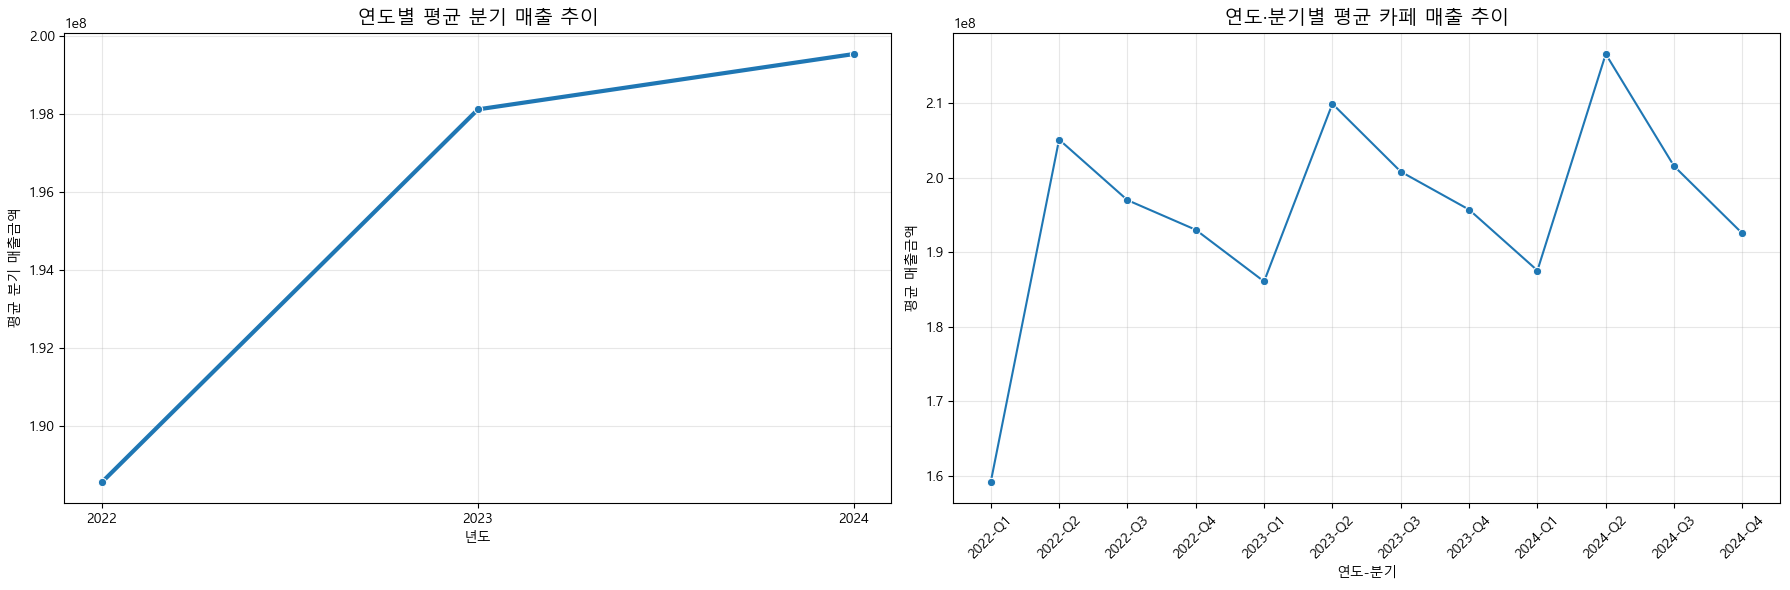

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# 1. 연도별 평균 매출
sns.lineplot(
    data=yearly_sales,
    x='년도',
    y='분기_매출금액',
    marker='o',
    linewidth=3,
    ax=axes[0]
)

axes[0].set_title('연도별 평균 분기 매출 추이', fontsize=14)
axes[0].set_xlabel('년도')
axes[0].set_ylabel('평균 분기 매출금액')

axes[0].grid(True, alpha=0.3)

# 2. 연도-분기별 평균 매출
sns.lineplot(
    data=quarter_sales,
    x='연도_분기',
    y='분기_매출금액',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('연도·분기별 평균 카페 매출 추이', fontsize=14)
axes[1].set_xlabel('연도-분기')
axes[1].set_ylabel('평균 매출금액')

axes[1].tick_params(axis='x', rotation=45)

axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### 분석 결과

분기별 평균 매출 추이를 확인한 결과,
1분기에는 상대적으로 매출이 감소하고 2분기에는 매출이 증가하는 반복 패턴이 나타났다.

특히 2분기 매출이 매년 높은 수준을 보이는 것으로 보아,
카페 산업은 계절성과 외부 활동 증가의 영향을 받는 업종임을 확인할 수 있었다.

또한 연도별 최고 매출 수준이 점진적으로 증가하는 흐름이 관찰되어,
전체 카페 시장 규모 역시 완만한 성장세를 보이는 것으로 해석할 수 있다.

## 3-2. (COVID-19)거리두기 해제 전·후 매출 비교

카페 산업은 외부 활동과 대면 소비의 영향을 크게 받는 업종이다.

이에 따라 거리두기 해제 전후의 평균 매출 차이를 비교하여,
외부 환경 변화가 카페 매출에 미친 영향을 탐색하였다.

분석을 위해 거리두기 시기와 해제 이후 시기를 구분하는 파생변수를 생성하였다.

**가설 1**
**코로나 거리두기 해체 이후 카페 매출은 증가했을 것이다.**

- 분석 목적 : 사회적 거리두기 완화가 오프라인 소비 회복에 영향을 미쳤는지 확인한다.

In [11]:
df['년도'] = pd.to_numeric(df['년도'], errors='coerce')
df['분기'] = pd.to_numeric(df['분기'], errors='coerce')
df['분기_매출금액'] = pd.to_numeric(df['분기_매출금액'], errors='coerce')

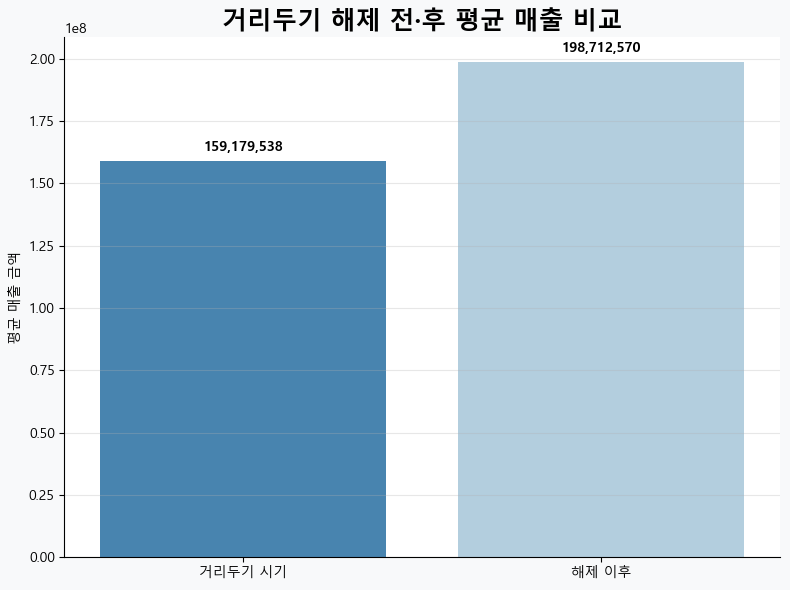

In [12]:
# 거리두기 해제 여부 변수 생성
df['거리두기_해제_이후'] = np.where(
    (df['년도'] == 2022) & (df['분기'] < 2),
    0,
    1
)

# 거리두기 해제 전·후 평균 매출 계산
covid_sales = (
    df.groupby('거리두기_해제_이후')['분기_매출금액']
    .mean()
    .reset_index()
)

# 시각화
fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='거리두기_해제_이후',
    y='분기_매출금액',
    data=covid_sales,
    palette='Blues_r',
    ax=ax
)

# 막대 위 수치 표시
for p in barplot.patches:
    height = p.get_height()

    barplot.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# 제목 및 라벨
ax.set_title(
    '거리두기 해제 전·후 평균 매출 비교',
    fontsize=18,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('평균 매출 금액')

# x축 라벨 변경
ax.set_xticks([0, 1])

ax.set_xticklabels([
    '거리두기 시기',
    '해제 이후'
])

# grid 스타일
ax.grid(axis='y', alpha=0.3)

# 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 분석 결과

거리두기 해제 이후 평균 매출 수준이 이전 시기 대비 높게 나타났다.

이는 외부 활동 증가와 대면 소비 회복이 카페 매출에 영향을 미쳤을 가능성을 시사한다.

다만 단일 변수만으로 직접적인 인과관계를 단정하기는 어려우며,
계절성 및 기타 외부 요인 역시 함께 작용했을 가능성이 존재한다.

## 3-3. 날씨 변수와 매출 관계 분석

카페 산업은 계절성과 외부 활동의 영향을 크게 받는 업종이므로,
날씨 요인이 매출 변화와 어떤 관계를 가지는지 분석하였다.

이를 위해 기온, 강수량, 풍속, 습도, 기압 등 주요 기상 변수와
분기 매출금액 간의 상관관계를 확인하였다.

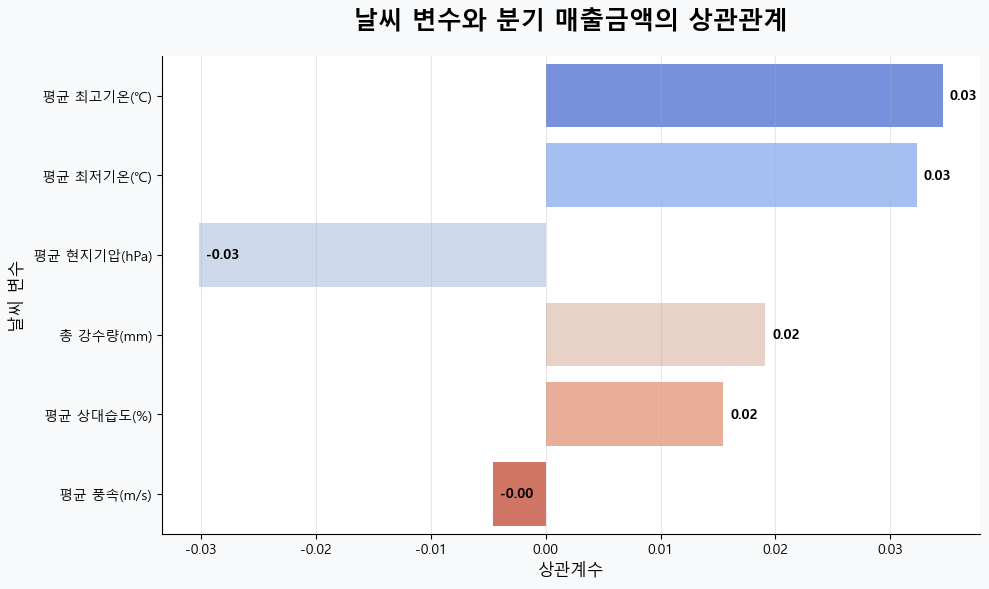

In [13]:
# 날씨 변수
weather = [
    '평균 최저기온(℃)',
    '평균 최고기온(℃)',
    '총 강수량(mm)',
    '평균 풍속(m/s)',
    '평균 상대습도(%)',
    '평균 현지기압(hPa)'
]

# 상관계수 계산
correlations = df[weather + ['분기_매출금액']].corr(method='pearson')

sales_corr = correlations['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
strongest_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

strongest_corr_df = strongest_corr.to_frame(name='Correlation')

# figure 생성
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

# 막대 그래프
barplot = sns.barplot(
    x='Correlation',
    y=strongest_corr_df.index,
    data=strongest_corr_df,
    palette='coolwarm',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(5, 0),
        textcoords='offset points'
    )

# 제목 및 라벨
ax.set_title(
    '날씨 변수와 분기 매출금액의 상관관계',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('상관계수', fontsize=12)
ax.set_ylabel('날씨 변수', fontsize=12)

# grid 스타일
ax.grid(axis='x', alpha=0.3)

# 축 스타일 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

날씨 변수와 분기 매출금액 간의 상관관계를 확인한 결과,
모든 변수의 상관계수가 0에 가까운 수준으로 나타났다.

이는 날씨 변수 단독으로는 카페 매출 변동을 충분히 설명하기 어렵다는 것을 의미한다.

특히 카페 매출은 단기적인 기상 변화보다는
상권 규모, 유동인구, 직장인구, 소비 수준과 같은 구조적 요인의 영향을 더 크게 받을 가능성이 존재한다.

또한 본 분석은 선형 관계 기반의 상관분석이므로,
비선형적 영향 관계까지는 충분히 반영하지 못할 수 있다.

### **추가적으로 고려한 분석 관점**

연도별 평균 매출액이 전반적으로 증가하는 흐름이 관찰되었으나,
이는 단순한 시장 성장뿐 아니라 물가 상승에 따른 명목적 증가가 함께 반영되었을 가능성이 존재한다.

따라서 소비자물가지수(CPI)를 활용한 실질 매출 분석이나,
연도별 커피 소비량 데이터를 활용한 시장 규모 분석 역시 의미 있는 추가 연구 방향이 될 수 있다.

다만 본 프로젝트에서는 상권 특성과 매출 예측 모델 구축에 집중하기 위해,
해당 분석은 향후 확장 가능성으로 남겨두었다.

## 3-4. 상권 변화 지표별 매출 분석

상권의 성장·축소·정체 여부에 따라 카페 매출 수준이 달라지는지 확인하기 위해,
상권 변화 지표별 매출 분포와 분기별 매출 추이를 비교하였다.

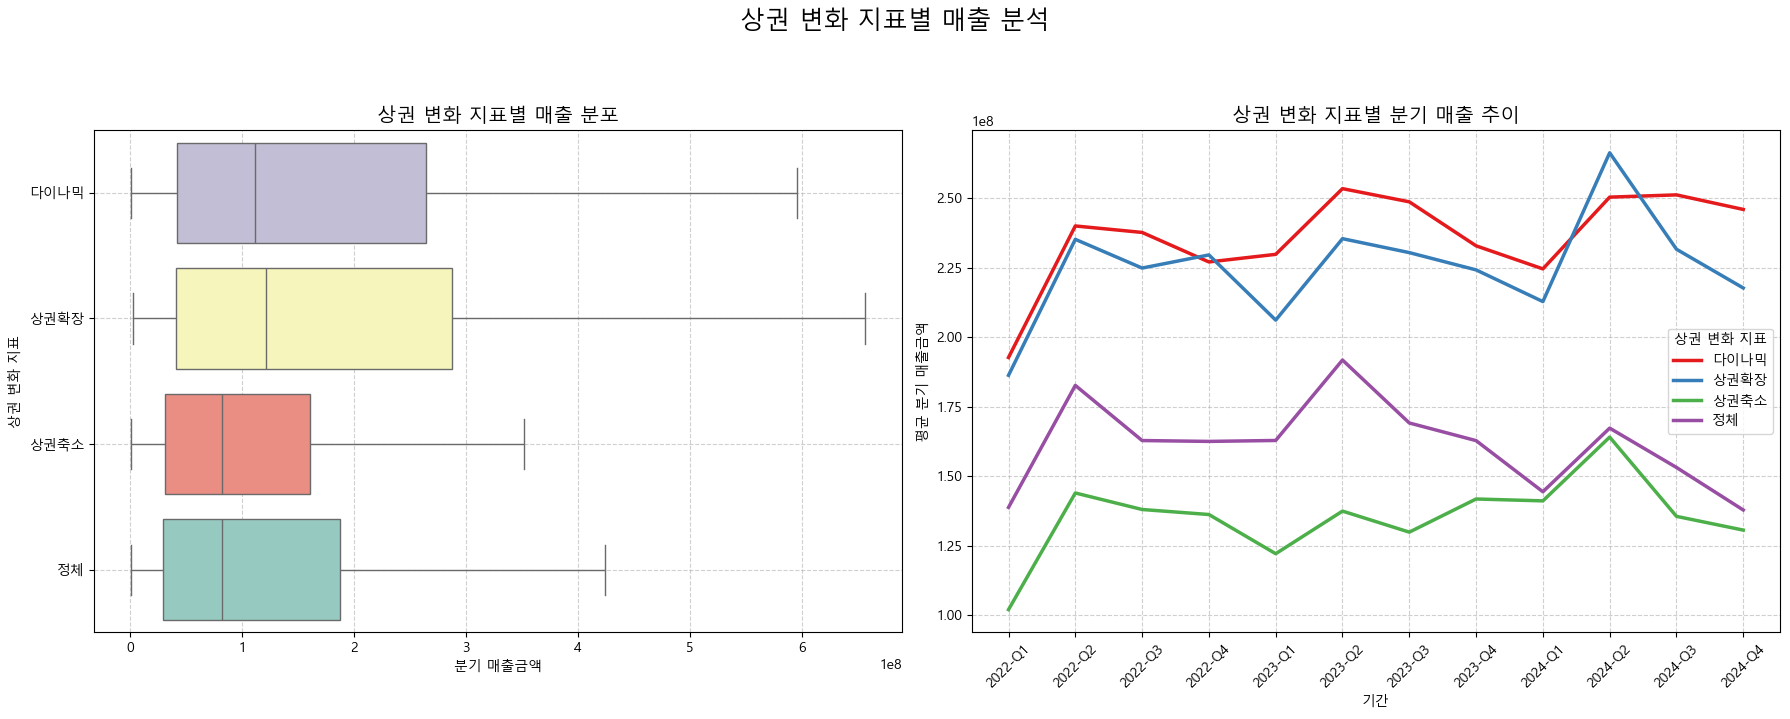

In [14]:
market_change_df = df.copy()

market_change_df['기간'] = (
    market_change_df['년도'].astype(str) + '-Q' +
    market_change_df['분기'].astype(str)
)

market_change_df = market_change_df.sort_values(by=['년도', '분기'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('상권 변화 지표별 매출 분석', fontsize=18, y=1.02)

# 매출 분포
sns.boxplot(
    ax=axes[0],
    data=market_change_df,
    y='상권_변화_지표_명',
    x='분기_매출금액',
    palette='Set3',
    order=['다이나믹', '상권확장', '상권축소', '정체'],
    hue='상권_변화_지표_명',
    showfliers=False,
    legend=False
)

axes[0].set_title('상권 변화 지표별 매출 분포', fontsize=14)
axes[0].set_xlabel('분기 매출금액')
axes[0].set_ylabel('상권 변화 지표')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 매출 추이
sns.lineplot(
    ax=axes[1],
    data=market_change_df,
    x='기간',
    y='분기_매출금액',
    hue='상권_변화_지표_명',
    hue_order=['다이나믹', '상권확장', '상권축소', '정체'],
    palette='Set1',
    linewidth=2.5,
    errorbar=None
)

axes[1].set_title('상권 변화 지표별 분기 매출 추이', fontsize=14)
axes[1].set_xlabel('기간')
axes[1].set_ylabel('평균 분기 매출금액')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='상권 변화 지표')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 분석 결과

상권 변화 지표별로 매출 분포와 추이에 차이가 나타났다.

특히 다이나믹 또는 상권확장 유형의 상권은 상대적으로 높은 매출 수준을 보이는 경향이 있으며,
이는 상권 활성도와 성장성이 카페 매출에 영향을 미칠 가능성을 시사한다.

반면 상권축소 또는 정체 유형은 상대적으로 낮은 매출 구간에 분포하는 경향이 있어,
입지 선정 시 상권의 현재 규모뿐 아니라 변화 방향성도 함께 고려할 필요가 있다.

- 상권확장 (LH): 새로운 가게들이 생기고, 한번 상권에 자리를 잡으면 평균적으로 오래가는 상권
- 정체 (HH): 개업과 폐업이 모두 적어 변화가 거의 없는 안정적이거나 침체된 상권
- 상권축소 (HL): 개업보다 폐업이 많아 쇠퇴하고 있는 위험 상권, 잘 되는 곳은 오래 버티지만, 한번 망하기 시작하면 빠르게 정리되는 상권
- 다이나믹 (LL): 가게들이 쉽게 들어왔다가 쉽게 망해서 나가는,  기회와 위험이 공존하는 불안정한 상권

## 3-5. 상권 안정성과 매출 관계 분석

상권의 운영 지속 기간과 폐업 특성은
상권 안정성과 시장 경쟁 강도를 반영할 가능성이 존재한다.

이에 따라 운영 기간 및 폐업 기간과 매출 간의 관계를 분석하였다.

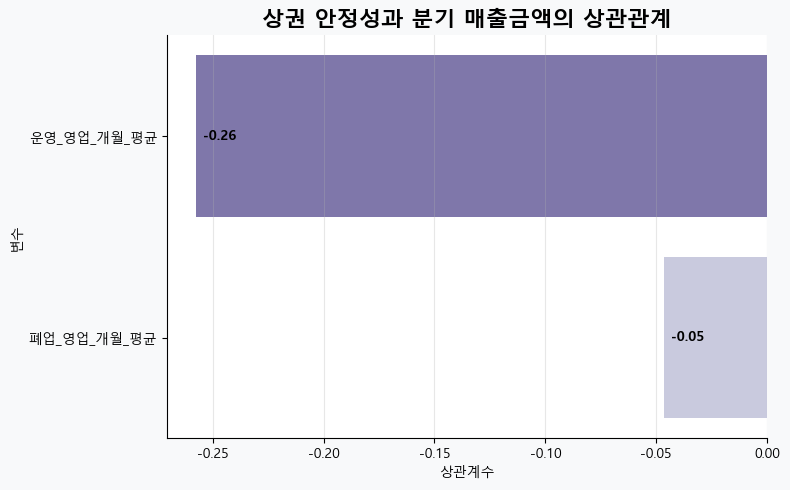

In [15]:
stability_features = [
    '운영_영업_개월_평균',
    '폐업_영업_개월_평균'
]

stability_corr = (
    df[stability_features + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = stability_corr['분기_매출금액'].drop('분기_매출금액')

sales_corr_df = sales_corr.to_frame(name='Correlation')

fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=sales_corr_df.index,
    data=sales_corr_df,
    palette='Purples_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '상권 안정성과 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

운영 영업 개월 평균은 분기 매출금액과 약한 음의 상관관계를 나타냈다.

이는 운영 기간이 긴 상권이 반드시 높은 매출을 의미하지는 않으며,
오히려 경쟁이 안정화된 성숙 상권일 가능성을 시사한다.

반면 신규 유입이 활발한 성장형 상권은 상대적으로 운영 기간이 짧더라도
높은 매출 수준을 보일 가능성이 존재한다.

폐업 영업 개월 평균은 매출과의 관계가 매우 약하게 나타나,
단일 변수만으로는 매출 수준을 충분히 설명하기 어려운 것으로 확인되었다.

## 3-6. 상권 생애주기별 매출 분포 분석

운영 영업 개월 평균을 기준으로 상권의 생애주기를 구분하고,
단계별 매출 분포 차이를 추가적으로 분석하였다.

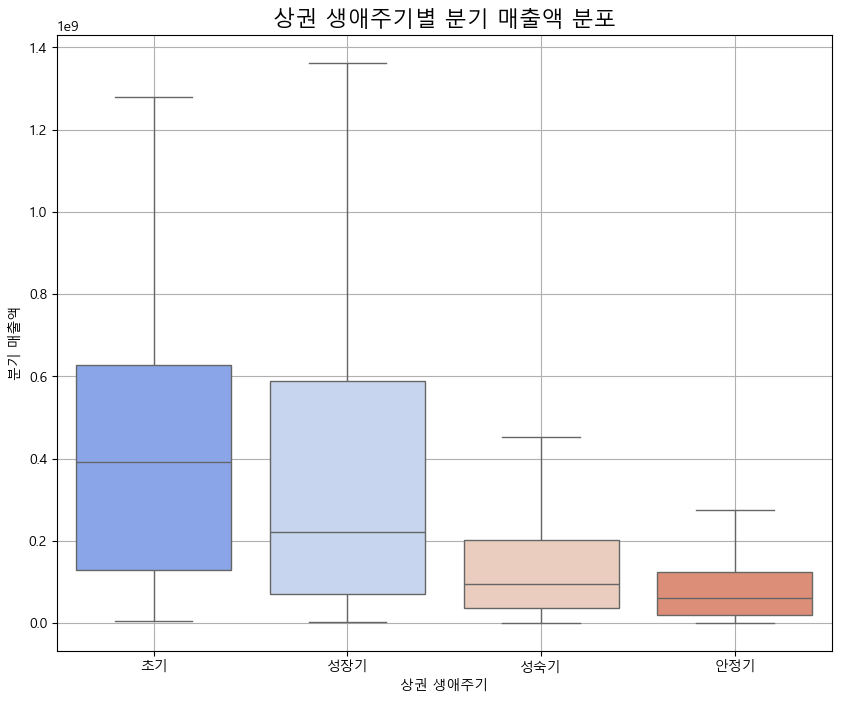

In [16]:
# 운영 기간 기준 상권 생애주기 구분
bins = [0, 60, 80, 120, float('inf')]

labels = ['초기', '성장기', '성숙기', '안정기']

df['상권_생애주기'] = pd.cut(
    df['운영_영업_개월_평균'],
    bins=bins,
    labels=labels,
    right=False
)

# 상권 생애주기별 매출 분포 시각화
plt.figure(figsize=(10, 8))

sns.boxplot(
    data=df,
    x='상권_생애주기',
    y='분기_매출금액',
    palette='coolwarm',
    showfliers=False,
    order=['초기', '성장기', '성숙기', '안정기']
)

plt.title(
    '상권 생애주기별 분기 매출액 분포',
    fontsize=16
)

plt.xlabel('상권 생애주기')
plt.ylabel('분기 매출액')

plt.grid(True)

plt.show()

### 분석 결과

운영 기간을 기준으로 상권 생애주기를 구분한 결과,
단계별로 매출 분포 차이가 나타나는 경향을 확인할 수 있었다.

특히 일부 성장 단계 상권은 상대적으로 높은 매출 분포를 보였으며,
이는 신규 유입과 상권 활성화의 영향을 받을 가능성을 시사한다.

반면 운영 기간이 긴 안정형 상권은
매출 변동성이 상대적으로 낮은 특징을 보였다.

## 3-7. 자치구별 매출 분포 분석

서울시 자치구별 평균 매출 수준 차이를 확인하여,
지역별 상권 규모와 소비 집중도의 차이를 탐색하였다.

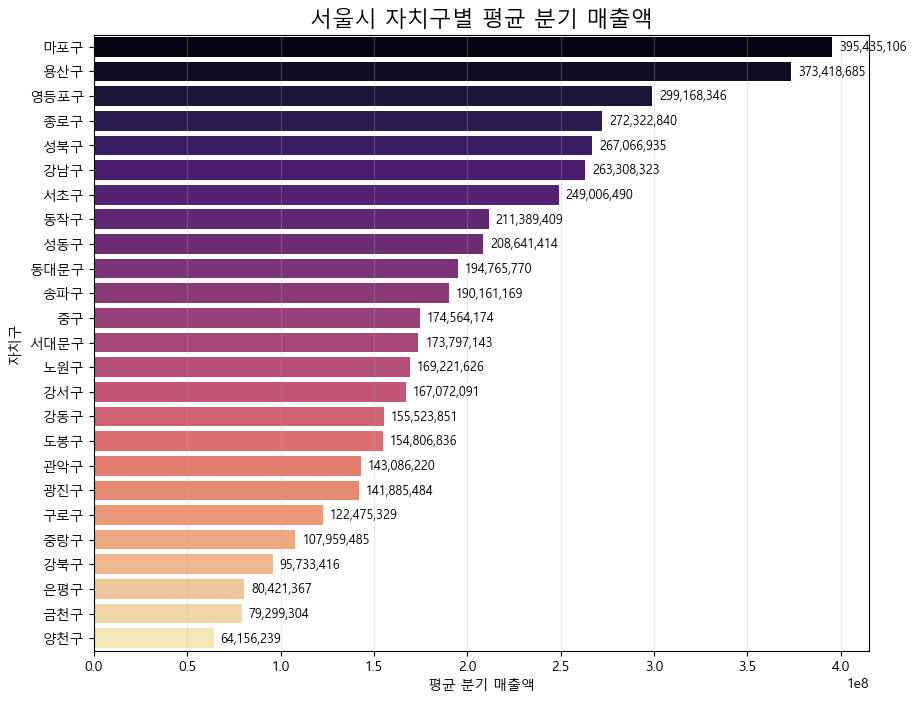

In [17]:
gu_sales_sorted = (
    df.groupby('자치구')['분기_매출금액']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

barplot = sns.barplot(
    x=gu_sales_sorted.values,
    y=gu_sales_sorted.index,
    palette='magma'
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:,.0f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title(
    '서울시 자치구별 평균 분기 매출액',
    fontsize=16
)

plt.xlabel('평균 분기 매출액')
plt.ylabel('자치구')

plt.grid(axis='x', alpha=0.3)

plt.show()

In [18]:
gu_sales_rank = df.groupby('자치구')['분기_매출금액'].mean().sort_values(ascending=False)

quantiles = gu_sales_rank.quantile([0.3, 0.7]).to_dict()
tier_low = quantiles[0.3]
tier_high = quantiles[0.7]

def assign_tier(gu_name):
    avg_sale = gu_sales_rank.loc[gu_name]
    if avg_sale >= tier_high:
        return '상위'
    elif avg_sale < tier_low:
        return '하위'
    else:
        return '중위'


df['상권_등급'] = df['자치구'].apply(assign_tier) 

자치구별 평균 매출 수준을 기준으로 상권 등급(상위·중위·하위)을 구분하여,
지역별 상권 규모 차이를 반영하는 파생변수를 생성하였다.

## 3-8. 상권 규모 및 집객시설과 매출 관계 분석

카페 매출은 상권 규모와 주변 상업 인프라의 영향을 받을 가능성이 존재한다.

이에 따라 총 커피매장 수, 일반음식점 점포 수, 집객시설 수와
분기 매출금액 간의 관계를 분석하였다.

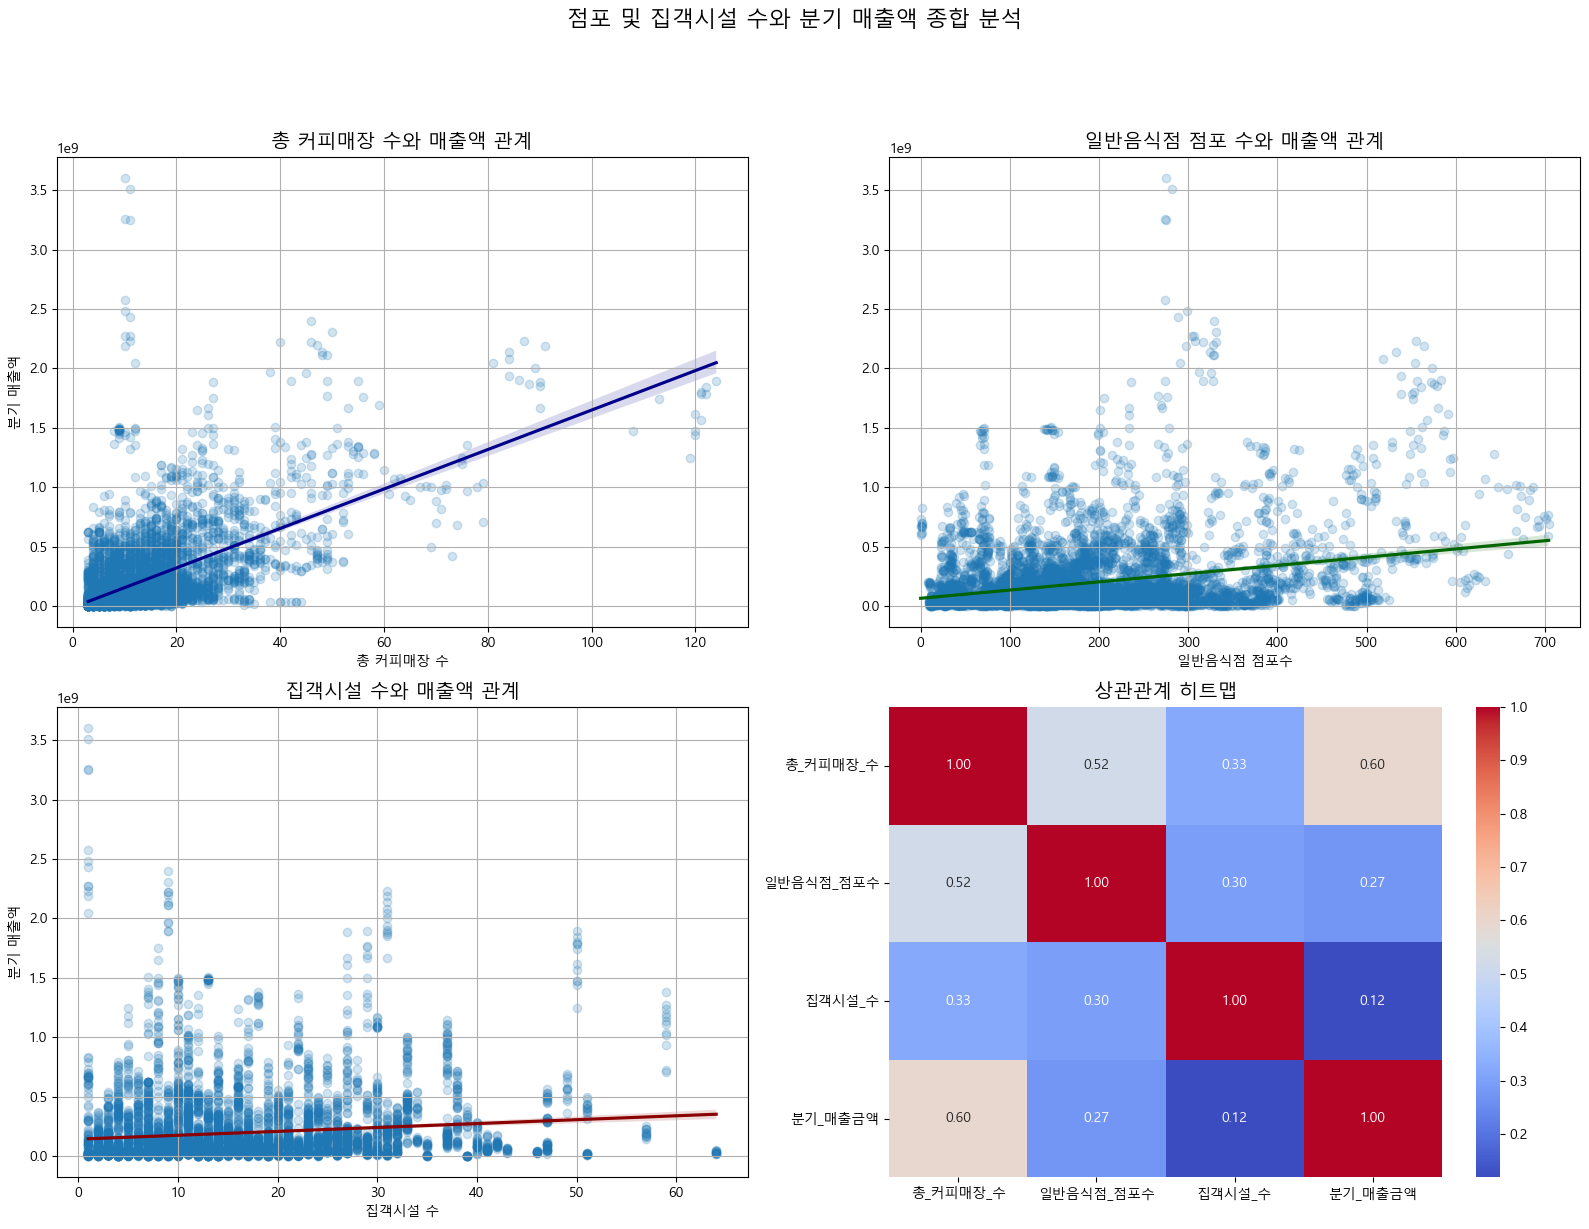

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('점포 및 집객시설 수와 분기 매출액 종합 분석', fontsize=16, y=1.02)


# --- 1행 1열: 총 커피매장 수 vs 매출액 ---
sns.regplot(
    ax=axes[0, 0],
    data=df,
    x='총_커피매장_수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkblue'}
)
axes[0, 0].set_title('총 커피매장 수와 매출액 관계', fontsize=14)
axes[0, 0].set_xlabel('총 커피매장 수')
axes[0, 0].set_ylabel('분기 매출액')
axes[0, 0].grid(True)


# --- 1행 2열: 일반음식점 점포 수 vs 매출액 ---
sns.regplot(
    ax=axes[0, 1],
    data=df,
    x='일반음식점_점포수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkgreen'}
)
axes[0, 1].set_title('일반음식점 점포 수와 매출액 관계', fontsize=14)
axes[0, 1].set_xlabel('일반음식점 점포수')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True)


# --- 2행 1열: 집객시설 수 vs 매출액 ---
sns.regplot(
    ax=axes[1, 0],
    data=df,
    x='집객시설_수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkred'}
)
axes[1, 0].set_title('집객시설 수와 매출액 관계', fontsize=14)
axes[1, 0].set_xlabel('집객시설 수')
axes[1, 0].set_ylabel('분기 매출액')
axes[1, 0].grid(True)


# --- 2행 2열: 상관관계 히트맵 ---
analysis_cols = ['총_커피매장_수', '일반음식점_점포수', '집객시설_수', '분기_매출금액']
correlation_matrix = df[analysis_cols].corr()
sns.heatmap(
    ax=axes[1, 1],
    data=correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
axes[1, 1].set_title('상관관계 히트맵', fontsize=14)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 분석 결과

총 커피매장 수는 분기 매출금액과 비교적 높은 양의 상관관계를 나타냈다.

이는 카페 밀집도가 높은 상권일수록 유동 수요와 소비 규모가 함께 증가할 가능성을 시사한다.

반면 일반음식점 점포 수와 집객시설 수는 상대적으로 낮은 상관관계를 보여,
단순한 상업 시설 규모만으로는 카페 매출 수준을 충분히 설명하기 어려운 것으로 나타났다.

특히 집객시설은 개수 자체보다 시설 유형이나 실제 유입 규모가
더 중요한 영향을 미칠 가능성이 존재한다.

## 3-9. 상주인구와 매출 관계 분석

카페 매출은 상권 내 거주 인구 규모와 소비 특성의 영향을 받을 가능성이 존재한다.

이에 따라 총 상주인구 및 연령대별 상주인구와
분기 매출금액 간의 관계를 분석하였다.

In [20]:
resident_age_cols = [
    '연령대_10_상주인구_수',
    '연령대_20_상주인구_수',
    '연령대_30_상주인구_수',
    '연령대_40_상주인구_수',
    '연령대_50_상주인구_수',
    '연령대_60_이상_상주인구_수'
]

resident_corr = (
    df[resident_age_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = resident_corr['분기_매출금액'].drop('분기_매출금액')

sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

resident_corr_df = sales_corr.to_frame(name='Correlation')

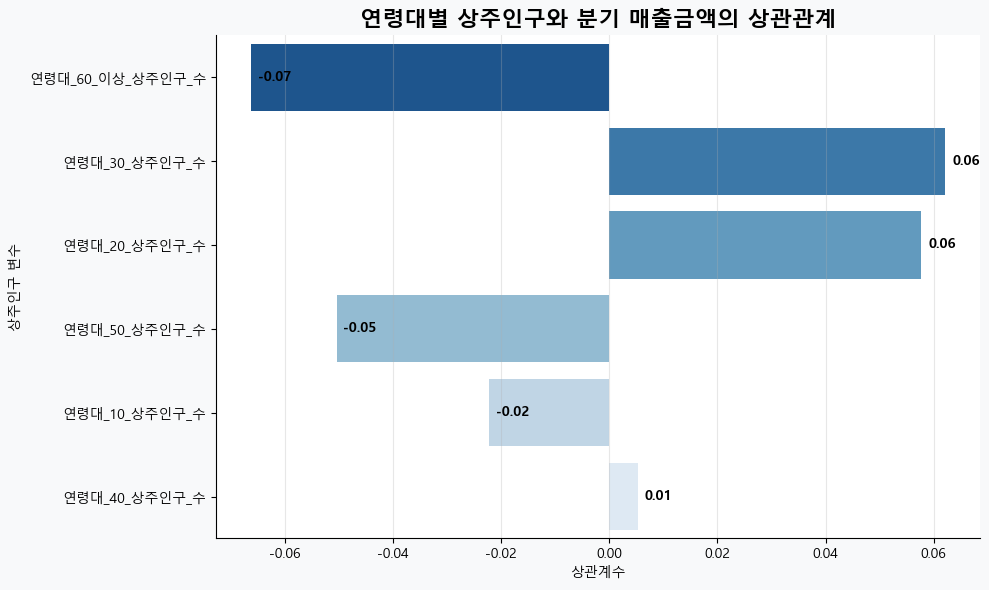

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=resident_corr_df.index,
    data=resident_corr_df,
    palette='Blues_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '연령대별 상주인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('상주인구 변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

연령대별 상주인구와 매출 간의 관계를 분석한 결과,
20~30대 상주인구는 상대적으로 높은 양의 상관관계를 나타냈다.

이는 젊은 연령층이 카페 주요 소비층과 연관될 가능성을 시사한다.

반면 50~60대 이상 상주인구는 음의 관계를 보였으며,
연령대별 소비 패턴 차이가 상권 매출 구조에 영향을 미칠 가능성을 확인할 수 있었다.

다만 전체적으로 상관계수 크기는 크지 않아,
상주인구 변수만으로 매출 수준을 충분히 설명하기에는 한계가 존재한다.

## 3-10. 직장인구와 매출 관계 분석

카페 산업은 오피스 상권과 업무 활동의 영향을 크게 받을 가능성이 존재한다.

이에 따라 총 직장인구 및 연령대별 직장인구와
분기 매출금액 간의 관계를 분석하였다.

In [22]:
worker_age_cols = [
    '연령대_10_직장_인구_수',
    '연령대_20_직장_인구_수',
    '연령대_30_직장_인구_수',
    '연령대_40_직장_인구_수',
    '연령대_50_직장_인구_수',
    '연령대_60_이상_직장_인구_수'
]

worker_corr = (
    df[worker_age_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = worker_corr['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

worker_corr_df = sales_corr.to_frame(name='Correlation')

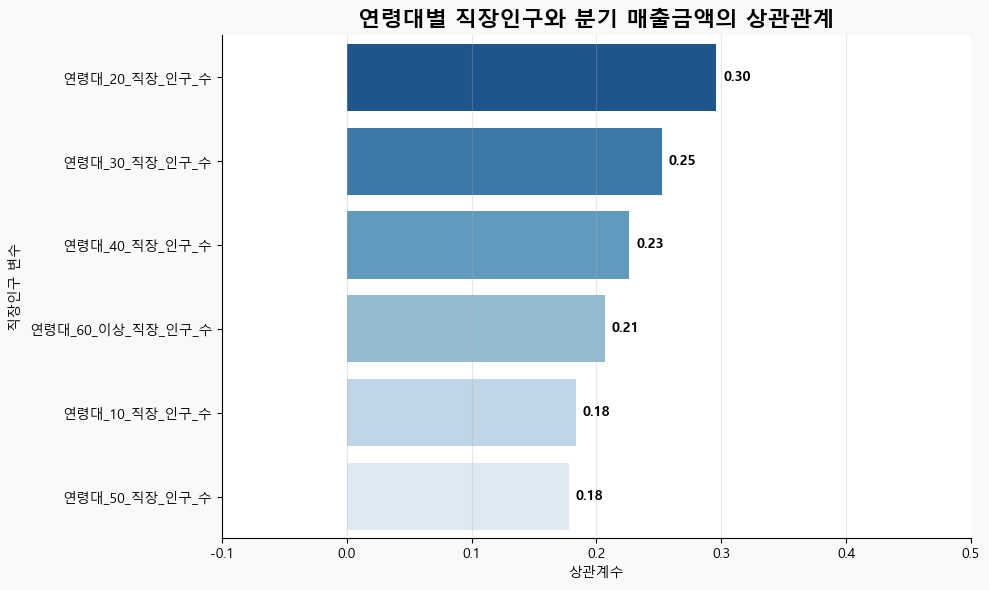

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=worker_corr_df.index,
    data=worker_corr_df,
    palette='Blues_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '연령대별 직장인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('직장인구 변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-0.1, 0.5)

plt.tight_layout()

plt.show()

### 분석 결과

직장인구 변수는 상주인구 변수보다 상대적으로 높은 상관관계를 나타냈다.

특히 20~30대 직장인구는 카페 매출과 비교적 높은 양의 관계를 보여,
오피스 상권과 업무 활동 기반 소비가 카페 산업에 중요한 영향을 미칠 가능성을 시사한다.

반면 상주인구 변수는 전반적으로 낮은 상관관계를 보여,
카페 산업은 단순 거주 인구보다 실제 활동 인구의 영향을 더 크게 받을 가능성이 있는 것으로 나타났다.

## 3-11. 유동인구와 매출 관계 분석


카페 산업은 실제 사람의 이동량과 활동 패턴의 영향을 크게 받을 가능성이 존재한다.

이에 따라 총 유동인구와 시간대·요일별 유동인구 특성이
분기 매출금액과 어떤 관계를 가지는지 분석하였다.

In [24]:
floating_cols = [
    '총_유동인구_수',
    '남성_유동인구_수',
    '여성_유동인구_수'
]

floating_corr = (
    df[floating_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = floating_corr['분기_매출금액'].drop('분기_매출금액')

floating_corr_df = sales_corr.to_frame(name='Correlation')

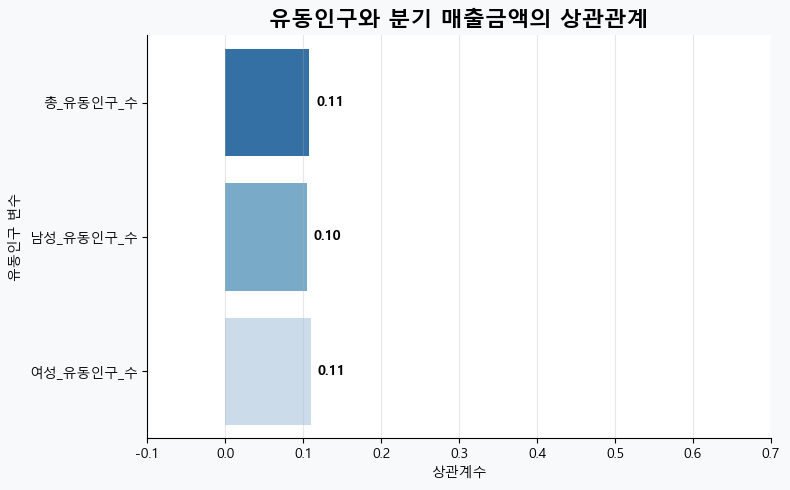

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=floating_corr_df.index,
    data=floating_corr_df,
    palette='Blues_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '유동인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('유동인구 변수')
ax.set_xlim(-0.1, 0.7)
ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-0.1, 0.7)

plt.tight_layout()

plt.show()

### 분석 결과

총 유동인구 변수는 분기 매출금액과 약한 양의 상관관계를 나타냈다.

이는 단순한 유동인구 규모 자체보다는,
실제 체류 시간이나 소비 목적을 가진 활동 인구 특성이 더 중요할 가능성을 시사한다.

특히 카페 산업은 단순 이동량보다
업무·생활 동선 기반의 소비 패턴 영향을 받을 가능성이 존재한다.

이에 따라 다음 단계에서는 시간대별 유동인구 특성을 추가적으로 분석하였다.

## 3-12. 시간대별 유동인구와 매출 관계 분석

카페 산업은 시간대별 활동 패턴과 생활 동선의 영향을 크게 받을 가능성이 존재한다.

이에 따라 시간대별 유동인구와 분기 매출금액 간의 관계를 분석하여,
어떤 시간대의 활동 인구가 카페 매출과 높은 관련성을 가지는지 확인하였다.

In [26]:
time_cols = [
    '시간대_00_06_유동인구_수',
    '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수',
    '시간대_21_24_유동인구_수'
]

time_corr = (
    df[time_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = time_corr['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

time_corr_df = sales_corr.to_frame(name='Correlation')

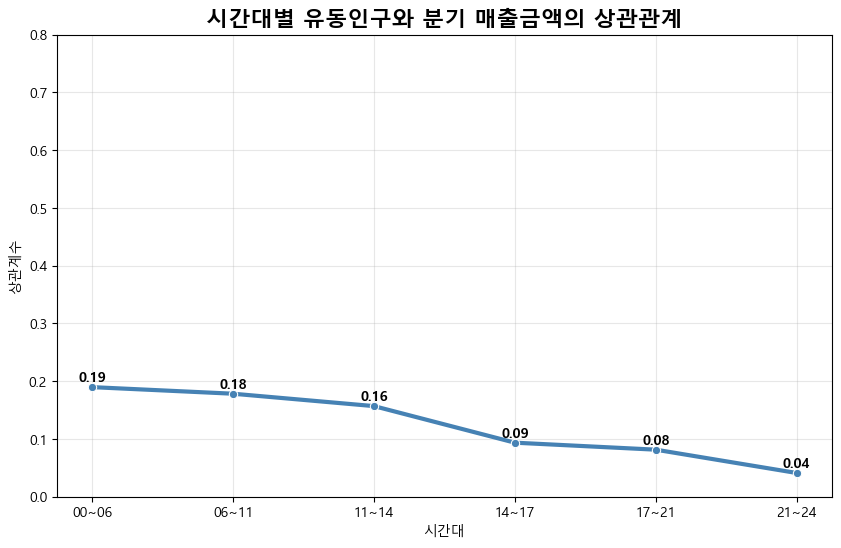

In [27]:
time_labels = [
    '00~06',
    '06~11',
    '11~14',
    '14~17',
    '17~21',
    '21~24'
]

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=time_labels,
    y=time_corr_df['Correlation'],
    marker='o',
    linewidth=3,
    color='steelblue'
)

# 값 표시
for i, value in enumerate(time_corr_df['Correlation']):

    plt.text(
        i,
        value + 0.01,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    '시간대별 유동인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('시간대')
plt.ylabel('상관계수')

plt.grid(True, alpha=0.3)

plt.ylim(0, 0.8)

plt.show()

### 분석 결과

시간대별 유동인구와 매출 간의 관계를 분석한 결과,
오전 시간대 유동인구가 상대적으로 높은 상관관계를 나타냈다.

특히 00 ~ 06시와 06 ~ 11시 시간대 유동인구는 다른 시간대 대비 높은 관계를 보여,
출근 및 아침 활동 중심 소비 패턴이 카페 매출에 영향을 미칠 가능성을 시사한다.

반면 오후 및 야간 시간대로 갈수록 상관관계가 점차 낮아지는 경향이 나타났다.

# EDA 종합 인사이트

EDA를 통해 카페 매출은 단순 거주 인구보다
직장인구 및 시간대별 활동 인구와 더 높은 관련성을 가지는 것으로 나타났다.

특히 상권 구조, 직장인구, 시간대별 유동인구 특성이
매출과 상대적으로 높은 관계를 보였으며,
이를 기반으로 예측 모델에 활용할 주요 변수를 선정하였다.

다음 단계에서는 EDA 결과를 기반으로
모델링을 위한 변수 선택 및 데이터 전처리를 수행하였다.

## Feature Engineering 

EDA 결과, 카페 매출은 단순 개별 변수보다
- 핵심 소비 연령층
- 시간대별 유동 패턴
- 상권 경쟁 수준
- 직장인 중심 상권 여부
등 복합적인 특성에 영향을 받을 가능성이 확인되었다.

이에 따라 비즈니스 관점을 반영한 파생변수를 생성하였다.

1. 핵심 소비층 비율
   
카페 핵심 소비층 (20~40대) 비중  , 실제 소비 가능 고객 밀도

In [28]:
df['핵심소비층_비율'] = (
    df['연령대_20_유동인구_수'] +
    df['연령대_30_유동인구_수'] +
    df['연령대_40_유동인구_수']
) / df['총_유동인구_수']

2. 피크타임 비율

출근/점심 핵심 시간대 유동량 비율


In [29]:
df['아침시간대_유동인구_비율'] = (
    df['시간대_00_06_유동인구_수'] +
    df['시간대_06_11_유동인구_수']
) / df['총_유동인구_수']

3. 경쟁강도

In [30]:
df['카페밀집도'] = (
    df['총_커피매장_수'] /
    df['총_유동인구_수']
)

4. 직장인 비율  : 오피스 상권 여부

In [31]:
df['직장인_비율'] = (
    df['총_직장_인구_수'] /
    df['총_유동인구_수']
)

5. 상권포화도

In [32]:
df['상권포화도'] = (
    df['일반음식점_점포수'] /
    df['집객시설_수']
)

## Preprocessing

모델 학습을 위해 목표 변수(Target)와 입력 변수(Feature)를 분리하였다.

목표 변수는 분기 매출금액으로 설정하였으며,
EDA 및 Feature Engineering을 통해 생성한 상권·인구·시간대 기반 변수들을 입력 변수로 활용하였다.

In [33]:
# =========================
# 사용할 컬럼 리스트 정리
# =========================

selected_cols = [

    # 시간 / 환경 변수
    '년도',
    '분기',
    '거리두기_해제_이후',

    '평균 최고기온(℃)',
    '총 강수량(mm)',

    # 상권 특성 변수
    '상권_변화_지표_명',
    '상권_생애주기',

    '총_커피매장_수',
    '집객시설_수',

    # 인구 특성 변수
    '총_직장_인구_수',
    '총_유동인구_수',

    # Feature Engineering 변수
    '핵심소비층_비율',
    '카페밀집도',
    '직장인_비율',
    '아침시간대_유동인구_비율',
    '상권포화도',

    # Target
    '분기_매출금액'
]

# 필요한 컬럼만 추출
df_model = df[selected_cols].copy()

# 확인
print(df_model.shape)
df_model.head()

(7404, 17)


,년도,분기,거리두기_해제_이후,평균 최고기온(℃),총 강수량(mm),상권_변화_지표_명,상권_생애주기,총_커피매장_수,집객시설_수,총_직장_인구_수,총_유동인구_수,핵심소비층_비율,카페밀집도,직장인_비율,아침시간대_유동인구_비율,상권포화도,분기_매출금액
0,2022,1,0,6.48,112.8,정체,성숙기,4,18.0,492.0,529340.0,0.387783,0.000008,0.000929,0.444410,1.222222,61342892
1,2022,2,1,24.36,421.7,정체,성숙기,4,18.0,492.0,581730.0,0.386413,0.000007,0.000846,0.432830,1.222222,89525560
2,2022,3,1,29.06,1018.6,정체,성숙기,4,18.0,492.0,577170.0,0.392461,0.000007,0.000852,0.424301,1.166667,89800497
3,2022,4,1,12.22,222.2,정체,성숙기,4,18.0,470.0,566740.0,0.385888,0.000007,0.000829,0.424643,1.333333,75913905
4,2022,1,0,6.48,112.8,정체,성숙기,7,18.0,1776.0,729450.0,0.377413,0.000010,0.002435,0.548187,3.555556,55734579


In [34]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 7404 entries, 0 to 8461
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   년도             7404 non-null   int64   
 1   분기             7404 non-null   int64   
 2   거리두기_해제_이후     7404 non-null   int64   
 3   평균 최고기온(℃)     7404 non-null   float64 
 4   총 강수량(mm)      7404 non-null   float64 
 5   상권_변화_지표_명     7404 non-null   str     
 6   상권_생애주기        7404 non-null   category
 7   총_커피매장_수       7404 non-null   int64   
 8   집객시설_수         7284 non-null   float64 
 9   총_직장_인구_수      7395 non-null   float64 
 10  총_유동인구_수       7396 non-null   float64 
 11  핵심소비층_비율       7396 non-null   float64 
 12  카페밀집도          7396 non-null   float64 
 13  직장인_비율         7387 non-null   float64 
 14  아침시간대_유동인구_비율  7396 non-null   float64 
 15  상권포화도          7284 non-null   float64 
 16  분기_매출금액        7404 non-null   int64   
dtypes: category(1), float64(10), int64(5), str(1)
mem

In [35]:
# 결측치 처리
# 수치형 컬럼 결측치 중앙값 대체
num_cols = df_model.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

In [36]:
# 범주형 변수 인코등 ( 상권_변화_지표_명 , 상권_생애주기)
df_model = pd.get_dummies(
    df_model,
    columns=['상권_변화_지표_명', '상권_생애주기'],
    drop_first=True
)

In [42]:
# 2022~2023년 학습, 2024년 테스트
train = df_model[df_model['년도'] < 2024]
test = df_model[df_model['년도'] == 2024]

X_train = train.drop(columns=['분기_매출금액'])
y_train = train['분기_매출금액']

X_test = test.drop(columns=['분기_매출금액'])
y_test = test['분기_매출금액']

print(X_train.shape)
print(X_test.shape)

print(train['년도'].unique())
print(test['년도'].unique())

(4936, 20)
(2468, 20)
[2022 2023]
[2024]


시간 흐름에 따른 예측 상황을 반영하기 위해 랜덤 분할이 아닌 시간 기준 분할을 적용하였다.  
2022~2023년 데이터를 학습 데이터로 사용하고, 2024년 데이터를 테스트 데이터로 설정하여  
미래 시점의 매출 예측 성능을 검증하였다.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
models = {
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(random_state=42),
    'LGBMRegressor': LGBMRegressor(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42)
}

predictions_dict = {}
importances_dict = {}
results_list = []

for name, model in models.items():
    print(f"--- {name} 모델 처리 중 ---")

    # 선형 모델은 스케일링 데이터 사용
    if name in ['Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    predictions_dict[name] = predictions

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results_list.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
    else:
        importances = np.zeros(X_train.shape[1])

    importances_dict[name] = pd.Series(importances, index=X_train.columns)

results_df = pd.DataFrame(results_list).sort_values(by='RMSE')
results_df

--- RandomForestRegressor 모델 처리 중 ---
--- XGBRegressor 모델 처리 중 ---
--- LGBMRegressor 모델 처리 중 ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001961 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1939
[LightGBM] [Info] Number of data points in the train set: 4936, number of used features: 20
[LightGBM] [Info] Start training from score 193352464.530592
--- Ridge 모델 처리 중 ---
--- Lasso 모델 처리 중 ---


,Model,MAE,RMSE,R2
1,XGBRegressor,6.965913e+07,1.195563e+08,0.829703
0,RandomForestRegressor,6.916906e+07,1.238713e+08,0.817188
2,LGBMRegressor,8.022051e+07,1.336553e+08,0.787169
3,Ridge,1.318739e+08,2.162325e+08,0.442936
4,Lasso,1.318998e+08,2.162594e+08,0.442798


XGBoost 모델이 가장 높은 성능을 보인 이유는  
카페 매출과 상권 특성 간의 비선형 관계를 효과적으로 학습했기 때문으로 해석된다.

특히 유동인구, 경쟁 강도, 상권 변화 지표 등 복합적인 상호작용을
트리 기반 부스팅 모델이 효과적으로 반영한 것으로 보인다.

반면 Ridge와 Lasso 등 선형 모델은 상대적으로 낮은 성능을 보였다.

이는 카페 매출이 단순 선형 관계보다
상권 특성·유동인구·시간대 등 다양한 변수 간 비선형 관계의 영향을 크게 받기 때문으로 해석된다.

# 7. Model Interpretation

## 7-1. XGBoost 변수 중요도 분석

최종 모델로 선정된 XGBoost 모델을 기반으로
카페 매출 예측에 영향을 미치는 핵심 변수를 분석하였다.

이를 통해 단순 예측을 넘어,
실제 고매출 상권의 주요 특성을 해석하고자 하였다.

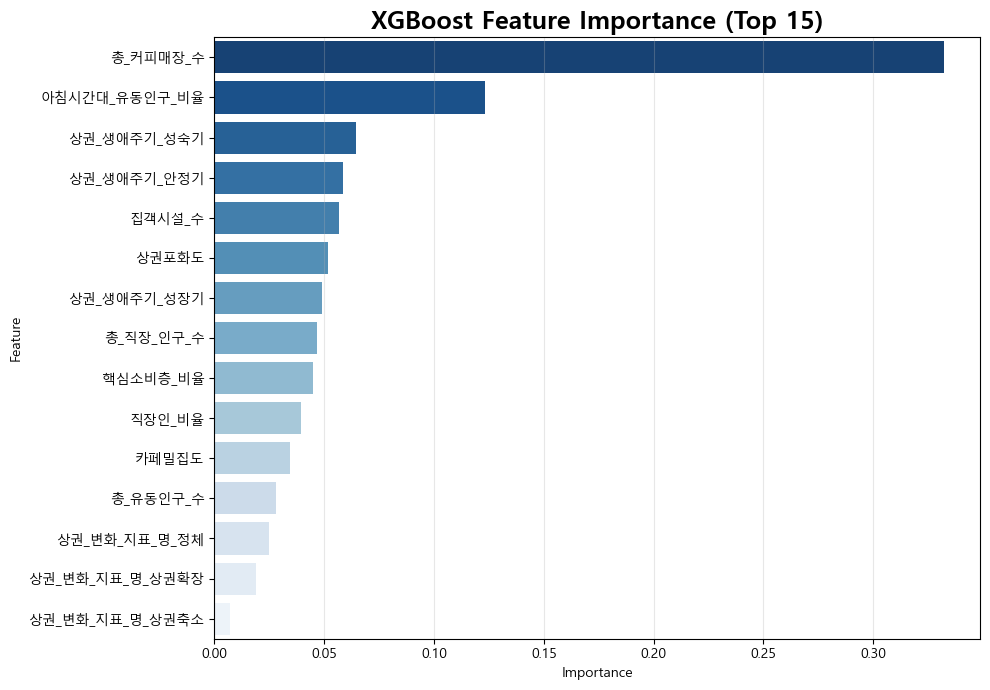

In [47]:
# XGBoost 변수 중요도 추출
xgb_importance = importances_dict['XGBRegressor']

# 상위 15개 변수 선택
top_features = xgb_importance.sort_values(ascending=False).head(15)

# 시각화
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette='Blues_r'
)

plt.title(
    'XGBoost Feature Importance (Top 15)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# =========================
# 총_커피매장_수 제거 버전
# =========================

# 컬럼 제거
X_train_v2 = X_train.drop(columns=['총_커피매장_수'])
X_test_v2 = X_test.drop(columns=['총_커피매장_수'])

# XGBoost 재학습
xgb_v2 = XGBRegressor(random_state=42)

xgb_v2.fit(X_train_v2, y_train)

# 예측
xgb_pred_v2 = xgb_v2.predict(X_test_v2)

# 성능 평가
rmse_v2 = np.sqrt(mean_squared_error(y_test, xgb_pred_v2))
r2_v2 = r2_score(y_test, xgb_pred_v2)

print(f'RMSE: {rmse_v2:,.0f}')
print(f'R2 Score: {r2_v2:.4f}')

RMSE: 124,980,507
R2 Score: 0.8139


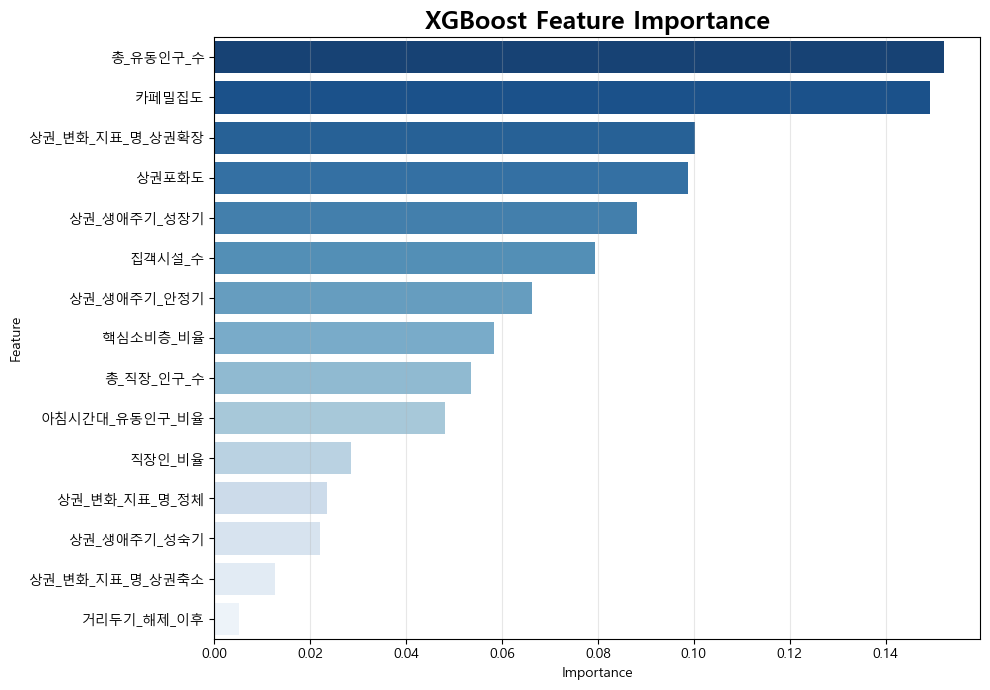

In [51]:
# 변수 중요도 추출
importance_v2 = pd.Series(
    xgb_v2.feature_importances_,
    index=X_train_v2.columns
)

# 상위 15개 변수
top_features_v2 = importance_v2.sort_values(
    ascending=False
).head(15)

# 시각화
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_features_v2.values,
    y=top_features_v2.index,
    palette='Blues_r'
)

plt.title(
    'XGBoost Feature Importance',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 분석 결과

XGBoost 변수 중요도 분석 결과,
카페 매출은 단순 유동인구 규모뿐 아니라
상권의 성장성, 소비층 특성, 시간대별 유동 패턴 등
복합적인 상권 구조의 영향을 받는 것으로 나타났다.

특히 총 유동인구 수와 카페밀집도는 가장 높은 중요도를 보이며,
유동량이 풍부하고 커피 소비가 활성화된 상권일수록
높은 매출 가능성을 가지는 경향이 확인되었다.

또한 상권확장, 성장기 상권 등의 변수 역시 높은 중요도를 보이며,
성숙된 대형 상권보다 성장 가능성이 높은 상권이
미래 매출 잠재력 측면에서 중요한 요소임을 확인할 수 있었다.

핵심소비층 비율과 직장인 인구, 아침시간대 유동인구 비율 역시
주요 변수로 나타나,
단순 유동량의 규모보다 실제 구매 가능성이 높은 소비층과
출근·오전 중심 활동 패턴이 카페 매출에 중요한 영향을 미치는 것으로 해석된다.

반면 거리두기 해제 여부 변수는 상대적으로 낮은 중요도를 보이며,
팬데믹 이후 외부 환경 변화보다
상권 자체의 구조적 특성이 매출에 더 큰 영향을 미치는 것으로 나타났다.

### 비즈니스 인사이트

성공적인 카페 상권은 단순히 사람이 많이 지나는 지역이 아니라,

- 구매력을 갖춘 핵심 소비층이 풍부하고
- 출근 및 오전 시간대 유동이 활발하며
- 성장 가능성이 높은 활성 상권 구조를 가진 지역

에서 형성되는 경향을 보였다.

특히 카페밀집도가 높은 지역은 단순 경쟁 과열이 아니라,
이미 커피 소비 수요가 검증된 목적지 상권으로 해석할 수 있으며,
집객시설과 음식점 밀집 지역은 추가적인 소비 시너지를 창출할 가능성이 높은 것으로 나타났다.

따라서 신규 출점 전략 수립 시,
단순 유동인구 규모보다 핵심 소비층의 질과 상권 성장성을 함께 고려하는 접근이 중요할 것으로 판단된다.